# Mall Customer Segmentation Project

## Problem Statement
The purpose of this project is to analyze customer behavior and purchasing patterns in a supermarket mall using membership card data. 
The mall wants to segment its customers into distinct groups to target marketing strategies and improve sales.

## Objective
- Use unsupervised ML techniques to identify customer segments.  
- Assign meaningful names to clusters.  
- Validate clusters using explainability (SHAP & LIME).  
- Finalize and save the best-performing model.


## 1. Importing Required Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pycaret.clustering import *
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import plotly.express as px
from lime.lime_tabular import LimeTabularExplainer
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## 2. Load Dataset and Explore

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\Documents\Datadivr\mall_customers.csv")

In [4]:
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [5]:
df.tail(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [6]:
df.shape

(200, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. Exploratory Data Analysis (EDA)
- Distribution of Age, Income, Spending Score.
- Gender distribution.
- Visualizes relationships between features (e.g., Age vs. Income, Income vs. Spending Score).
- Helps identify patterns such as younger customers spending more or income groups with different spending behaviors.

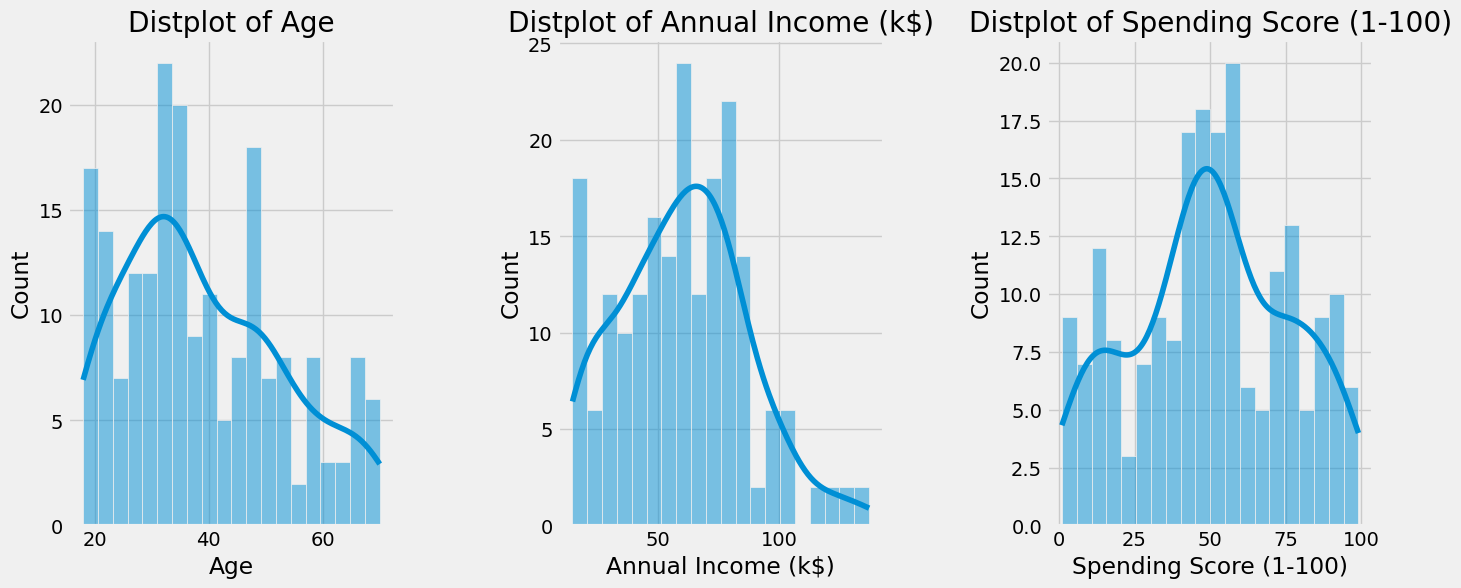

In [12]:
plt.figure(1 , figsize = (15 , 6))
n = 0 
for x in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace =0.5 , wspace = 0.5)
    sns.histplot(df[x], bins=20, kde=True)
    plt.title('Distplot of {}'.format(x))
plt.show()

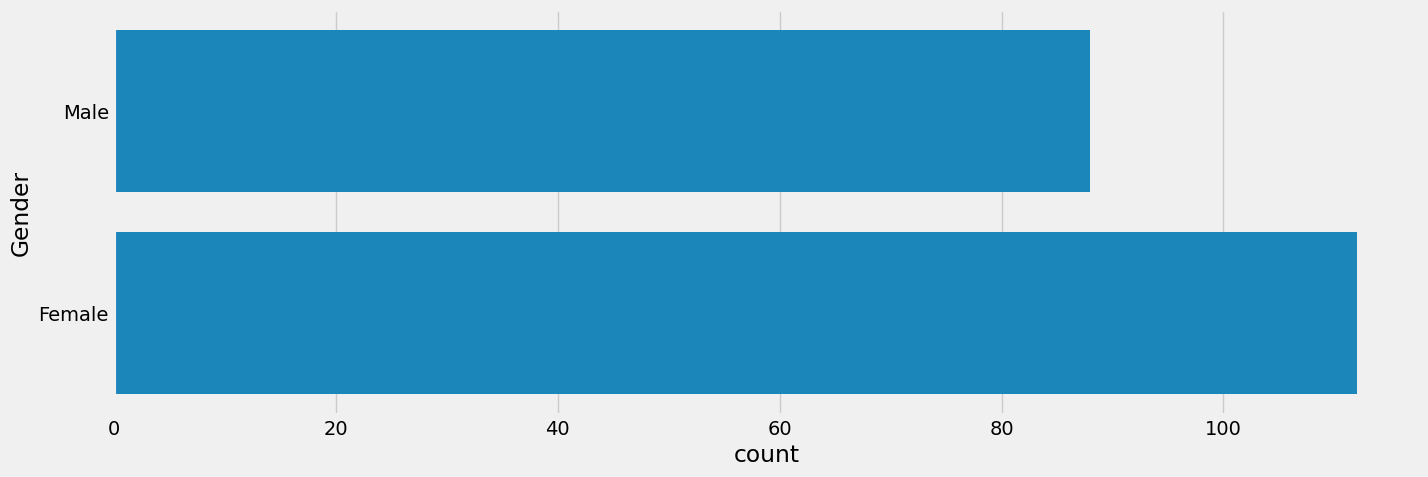

In [13]:
plt.figure(1 , figsize = (15 , 5))
sns.countplot(y = 'Gender' , data = df)
plt.show()

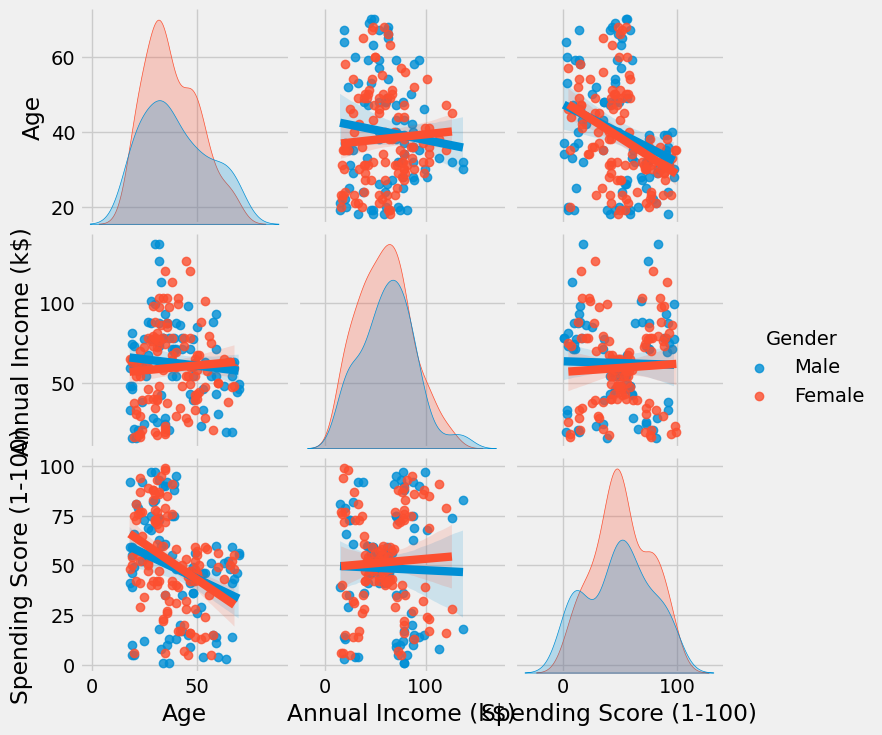

In [15]:
sns.pairplot(df[['Age','Annual Income (k$)','Spending Score (1-100)','Gender']],kind="reg", hue='Gender')
plt.show()

### Takeaways-
- Age Distribution: Majority of customers between 30–40 years. Senior customers are fewer.
- Annual Income Distribution: Most customers earn between 50k–70k.
- Spending Score: Concentrated around 40–60, indicating moderate spending.
- Gender Distribution: More females than males.
- Key insight: Younger customers spend more, older customers spend less.

## 4. Modeling with PyCaret
We will experiment with multiple clustering algorithms: KMeans, Hierarchical Clustering, and DBSCAN.

In [ ]:
exp = setup(data=df[['Age','Annual Income (k$)','Spending Score (1-100)']],
            normalize=True,
            session_id=123)


,Description,Value
0,Session id,123
1,Original data shape,"(200, 3)"
2,Transformed data shape,"(200, 3)"
3,Numeric features,3
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,Normalize,True
9,Normalize method,zscore


### Kmeans

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4040,125.6764,0.9308,0,0,0


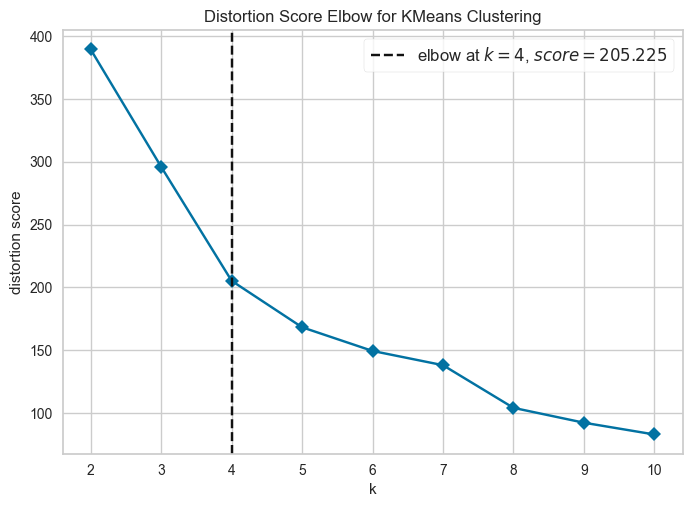

In [ ]:
plot_model(create_model('kmeans'), plot='elbow')


In [ ]:
kmeans = create_model('kmeans', num_clusters=7)
plot_model(kmeans,plot='tsne')


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3922,107.6345,0.8801,0,0,0


###  Hierarchical Clustering

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3615,102.0194,1.0164,0,0,0


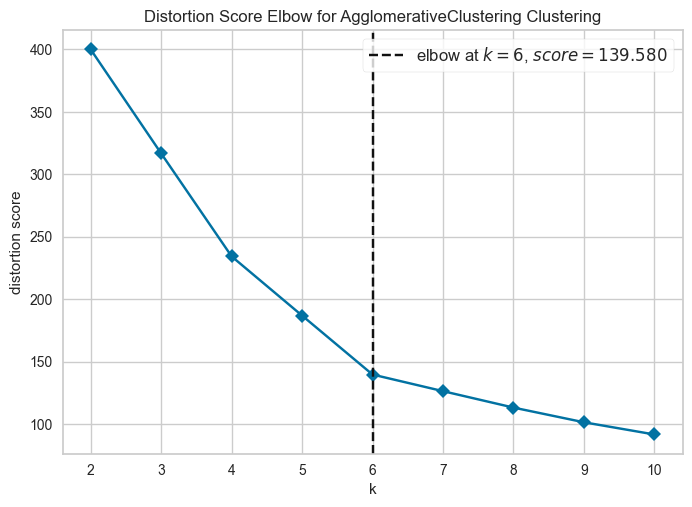

In [15]:
plot_model(create_model('hclust'), plot='elbow')

In [16]:

hclust = create_model('hclust', num_clusters=6)
plot_model(hclust,plot='tsne')

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4201,127.9865,0.8521,0,0,0


### DBSCAN

In [17]:
dbscan = create_model('dbscan')
plot_model(dbscan,plot='tsne')


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.1845,34.0705,1.7569,0,0,0


DBSCAN was not considered further as it did not perform well; in the 3D plot, data points from different clusters overlapped significantly, leading to poor separation.

## 5. Model Evaluation
Evaluate clustering results using metrics:  
- Silhouette Score (higher is better)  
- Calinski-Harabasz Index (higher is better)  
- Davies-Bouldin Index (lower is better)  

In [ ]:
# KMeans
kmeans_labels = assign_model(kmeans)['Cluster']
print("KMeans Metrics:")
print("Silhouette Score:", silhouette_score(df[['Age','Annual Income (k$)','Spending Score (1-100)']], kmeans_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(df[['Age','Annual Income (k$)','Spending Score (1-100)']], kmeans_labels))
print("Davies-Bouldin:", davies_bouldin_score(df[['Age','Annual Income (k$)','Spending Score (1-100)']], kmeans_labels))

# HClust
hclust_labels = assign_model(hclust)['Cluster']
print("\nHClust Metrics:")
print("Silhouette Score:", silhouette_score(df[['Age','Annual Income (k$)','Spending Score (1-100)']], hclust_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(df[['Age','Annual Income (k$)','Spending Score (1-100)']], hclust_labels))
print("Davies-Bouldin:", davies_bouldin_score(df[['Age','Annual Income (k$)','Spending Score (1-100)']], hclust_labels))


KMeans Metrics:
Silhouette Score: 0.4259850350242704
Calinski-Harabasz: 141.14960115734542
Davies-Bouldin: 0.8683823422256189

HClust Metrics:
Silhouette Score: 0.44308912983504156
Calinski-Harabasz: 159.45564315577582
Davies-Bouldin: 0.7684782366478475


### Interpretation of Metrics:
- Silhouette Score: Higher is better. HClust (0.44) > KMeans (0.42).
- Calinski-Harabasz: Higher is better. HClust (159) > KMeans (141).
- Davies-Bouldin: Lower is better. HClust (0.76) < KMeans (0.86).
- Best Model: Hierarchical Clustering (HClust) performed best across metrics and visualization.

## 6. Assign Clusters and Analyze Segments
Assign cluster labels and analyze mean values for Age, Income, Spending Score.

In [20]:
hclust_results  = assign_model(hclust)

In [21]:
print(hclust_results['Cluster'].value_counts())

Cluster
Cluster 0    45
Cluster 1    45
Cluster 2    39
Cluster 3    28
Cluster 4    22
Cluster 5    21
Name: count, dtype: int64


In [ ]:

hclust_summary = hclust_results.groupby('Cluster').mean()
print(hclust_summary)


                 Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                         
Cluster 0  27.377778           57.511111               45.844444
Cluster 1  56.400000           55.288889               48.355556
Cluster 2  32.692308           86.538462               82.128205
Cluster 3  43.892857           91.285714               16.678571
Cluster 4  44.318182           25.772727               20.272727
Cluster 5  24.809524           25.619048               80.238095


## 7. Manual Cluster Naming
Assign meaningful names to clusters based on their average Age, Income, and Spending Score.

In [23]:
cluster_names = {
    'Cluster 0': "Young Moderate Income & Moderate Spenders",
    'Cluster 1': "Older Moderate Income & Moderate Spenders",
    'Cluster 2': "Young High Income & High Spenders",
    'Cluster 3': "Middle-Aged High Income & Low Spenders",
    'Cluster 4': "Middle-Aged Low Income & Low Spenders",
    'Cluster 5': "Young Low Income & High Spenders"
}


In [24]:
hclust_results["Cluster_Name"] = hclust_results["Cluster"].map(cluster_names)


### Visualizing the clustered data points with assigned segment names.

In [ ]:
fig = px.scatter_3d(
    hclust_results,
    x="Age",
    y="Annual Income (k$)",
    z="Spending Score (1-100)",
    color="Cluster_Name", 
    hover_data=["Age", "Annual Income (k$)", "Spending Score (1-100)", "Cluster"]
)

fig.update_layout(title="Customer Segmentation (3D with Cluster Labels)")
fig.show()


## 8. Classification for Explainability
Train a Random Forest classifier with cluster labels as the target.  
This helps us explain the clusters with SHAP and LIME.

In [27]:
X = hclust_results[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
y = hclust_results['Cluster_Name']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

clf = RandomForestClassifier(random_state=123)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=123)

In [29]:
# Check accuracy
accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 1.00


## 9. SHAP (Global Explainability)
SHAP shows which features influence clustering most.

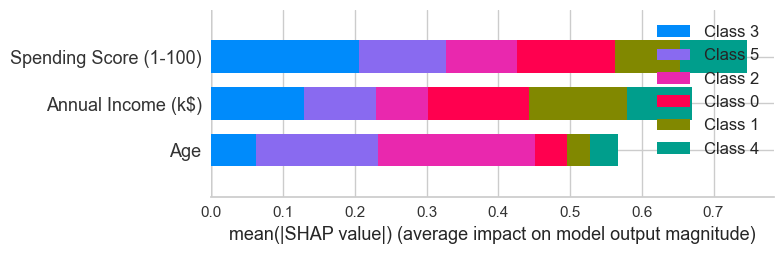

In [ ]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# Summary plot: shows feature importance across all clusters
shap.summary_plot(shap_values, X_test)


## 10. LIME (Local Explainability)
LIME explains the prediction for a single customer.

In [ ]:
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=[str(c) for c in clf.classes_],
    mode='classification'
)

instance_index = 5
print(X_test.iloc[instance_index].values)
exp = explainer.explain_instance(
    X_test.iloc[instance_index].values,
    clf.predict_proba,
    num_features=3
)


[49 62 56]


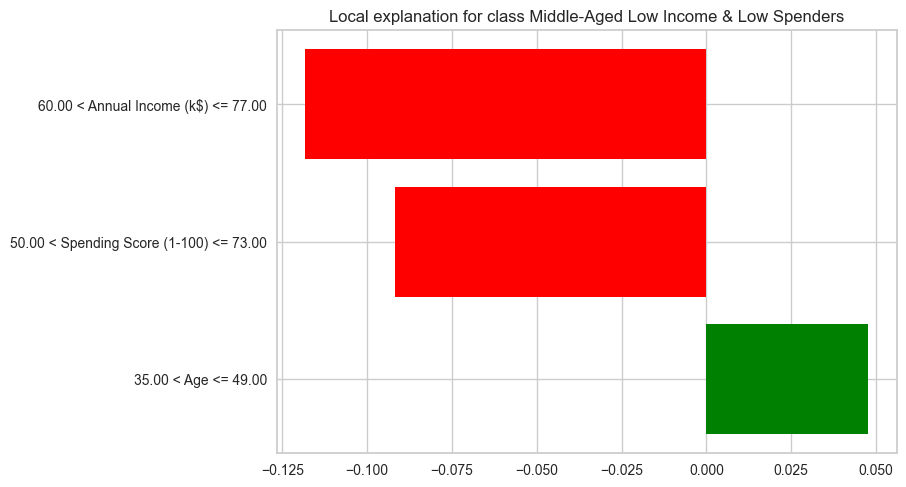

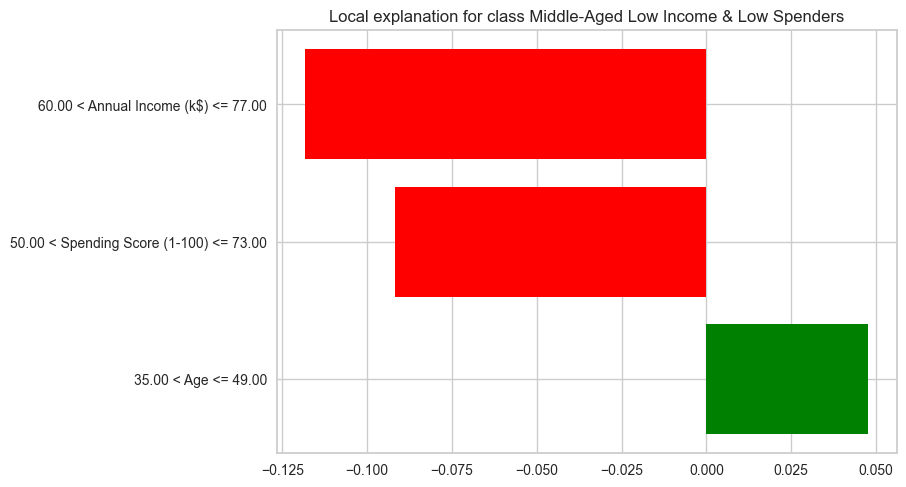

In [34]:
exp.as_pyplot_figure()


## 11. Final Model Training & Export
Train the selected model (Hierarchical Clustering) on the full dataset and save it.

In [70]:
final_model = create_model('hclust', num_clusters=6)
save_model(final_model, r'C:\Users\ASUS\Documents\Datadivr\mall_customer_segmentation');

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4431,159.4556,0.7685,0,0,0


Transformation Pipeline and Model Successfully Saved


### Observations & Outcomes 
1.	Best Algorithm: Hierarchical Clustering outperformed KMeans and DBSCAN in separation and metrics. 
2.	Customer Segments Identified: Six well-defined clusters with meaningful behavioral names. 
3.	Explainability: SHAP and LIME confirmed that Spending Score and Income drive segmentation, while Age provides secondary separation. 
4.	Business Value: The mall can now: 
    - Target Young High Income & High Spenders with premium product marketing. 
    - Offer discounts to Older High Income & Low Spenders to increase purchases. 
    - Design affordable bundles for Young Low Income & Low Spenders. 
